In [1]:
import sys
print(sys.executable)

c:\Users\yash2\AppData\Local\Programs\Python\Python311\python.exe


In [2]:
import pandas as pd
import tensorflow as tf
print(tf)
print(tf.__file__)


<module 'tensorflow' from 'c:\\Users\\yash2\\AppData\\Local\\Programs\\Python\\Python311\\Lib\\site-packages\\tensorflow\\__init__.py'>
c:\Users\yash2\AppData\Local\Programs\Python\Python311\Lib\site-packages\tensorflow\__init__.py


In [3]:
import tensorflow as tf
import streamlit as st
import PIL
import pandas as pd
import matplotlib
import numpy as np
import requests
import skimage

print("TensorFlow:", tf.__version__)
print("Streamlit:", st.__version__)
print("Pillow:", PIL.__version__)
print("Pandas:", pd.__version__)
print("Matplotlib:", matplotlib.__version__)
print("NumPy:", np.__version__)
print("Requests:", requests.__version__)
print("Scikit-image:", skimage.__version__)

TensorFlow: 2.15.0
Streamlit: 1.55.0
Pillow: 12.1.1
Pandas: 2.3.3
Matplotlib: 3.10.8
NumPy: 1.26.4
Requests: 2.32.5
Scikit-image: 0.26.0


In [4]:
import tensorflow as tf

print(tf.__version__)
print(tf.keras)

2.15.0
<KerasLazyLoader>


In [5]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import layers
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPool2D, Activation
from tensorflow.keras import Sequential

In [6]:
print(tf.__version__)

2.15.0


In [8]:
import os
# Walk through pizza_steak directory and list number of files
print("Train data: ")
for dirpath, dirnames, filenames in os.walk("seg_train"):
  print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")
print("Test data: ")
for dirpath, dirnames, filenames in os.walk("seg_test"):
  print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")
print("Prediction data: ")
for dirpath, dirnames, filenames in os.walk("seg_pred"):
  print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

Train data: 
There are 6 directories and 0 images in 'seg_train'.
There are 0 directories and 2191 images in 'seg_train\buildings'.
There are 0 directories and 2271 images in 'seg_train\forest'.
There are 0 directories and 2404 images in 'seg_train\glacier'.
There are 0 directories and 2512 images in 'seg_train\mountain'.
There are 0 directories and 2274 images in 'seg_train\sea'.
There are 0 directories and 2382 images in 'seg_train\street'.
Test data: 
There are 6 directories and 0 images in 'seg_test'.
There are 0 directories and 437 images in 'seg_test\buildings'.
There are 0 directories and 474 images in 'seg_test\forest'.
There are 0 directories and 553 images in 'seg_test\glacier'.
There are 0 directories and 525 images in 'seg_test\mountain'.
There are 0 directories and 510 images in 'seg_test\sea'.
There are 0 directories and 501 images in 'seg_test\street'.
Prediction data: 
There are 0 directories and 7301 images in 'seg_pred'.


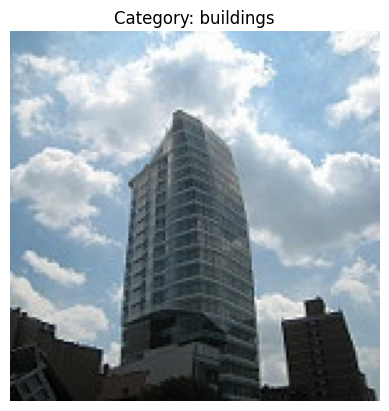

Image shape: (150, 150, 3)


In [13]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

# Choose which category you want to see
target_folder = 'buildings'
folder_path = f'seg_train/{target_folder}' # Path depends on how it unzipped

# Get a list of all image names in that folder
images = os.listdir(folder_path)

# Pick a random image from the list
random_image = random.choice(images)

# Read and show the image
img = mpimg.imread(os.path.join(folder_path, random_image))
plt.imshow(img)
plt.title(f"Category: {target_folder}")
plt.axis('off')
plt.show()

print(f"Image shape: {img.shape}")

In [14]:
import random
import matplotlib.pyplot as plt
def view_random_image(target_dir, target_class):
  # We will view image from here
  target_folder = target_dir + target_class

  # Get a random image path
  random_image = random.sample(os.listdir(target_folder), 1)

  # Read in the image and plot it using matplotlib
  img = mpimg.imread(target_folder+'/'+random_image[0])
  plt.imshow(img)
  plt.title(target_class)
  plt.axis('off');
  print(f"Image shape {img.shape}")

  return img

Image shape (150, 150, 3)


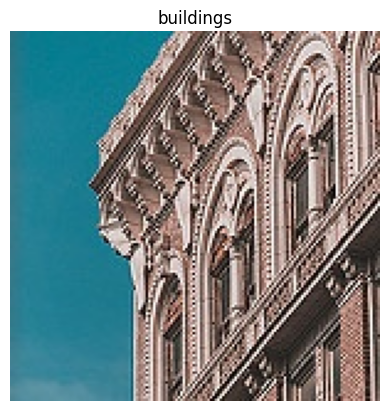

In [15]:
img = view_random_image(target_dir='seg_train/',
                  target_class='buildings')

In [17]:
# Get the class name programmatically
import pathlib
data_dir = pathlib.Path("seg_train")
class_names = np.array(sorted([item.name for item in data_dir.glob('*')]))
print(class_names)

['buildings' 'forest' 'glacier' 'mountain' 'sea' 'street']


Image shape (150, 150, 3)
Image shape (150, 150, 3)
Image shape (150, 150, 3)
Image shape (150, 150, 3)
Image shape (150, 150, 3)
Image shape (150, 150, 3)
Image shape (150, 150, 3)
Image shape (150, 150, 3)
Image shape (150, 150, 3)
Image shape (150, 150, 3)
Image shape (150, 150, 3)
Image shape (150, 150, 3)
Image shape (150, 150, 3)
Image shape (150, 150, 3)
Image shape (150, 150, 3)
Image shape (150, 150, 3)
Image shape (150, 150, 3)
Image shape (150, 150, 3)
Image shape (150, 150, 3)
Image shape (150, 150, 3)
Image shape (150, 150, 3)
Image shape (150, 150, 3)
Image shape (150, 150, 3)
Image shape (150, 150, 3)


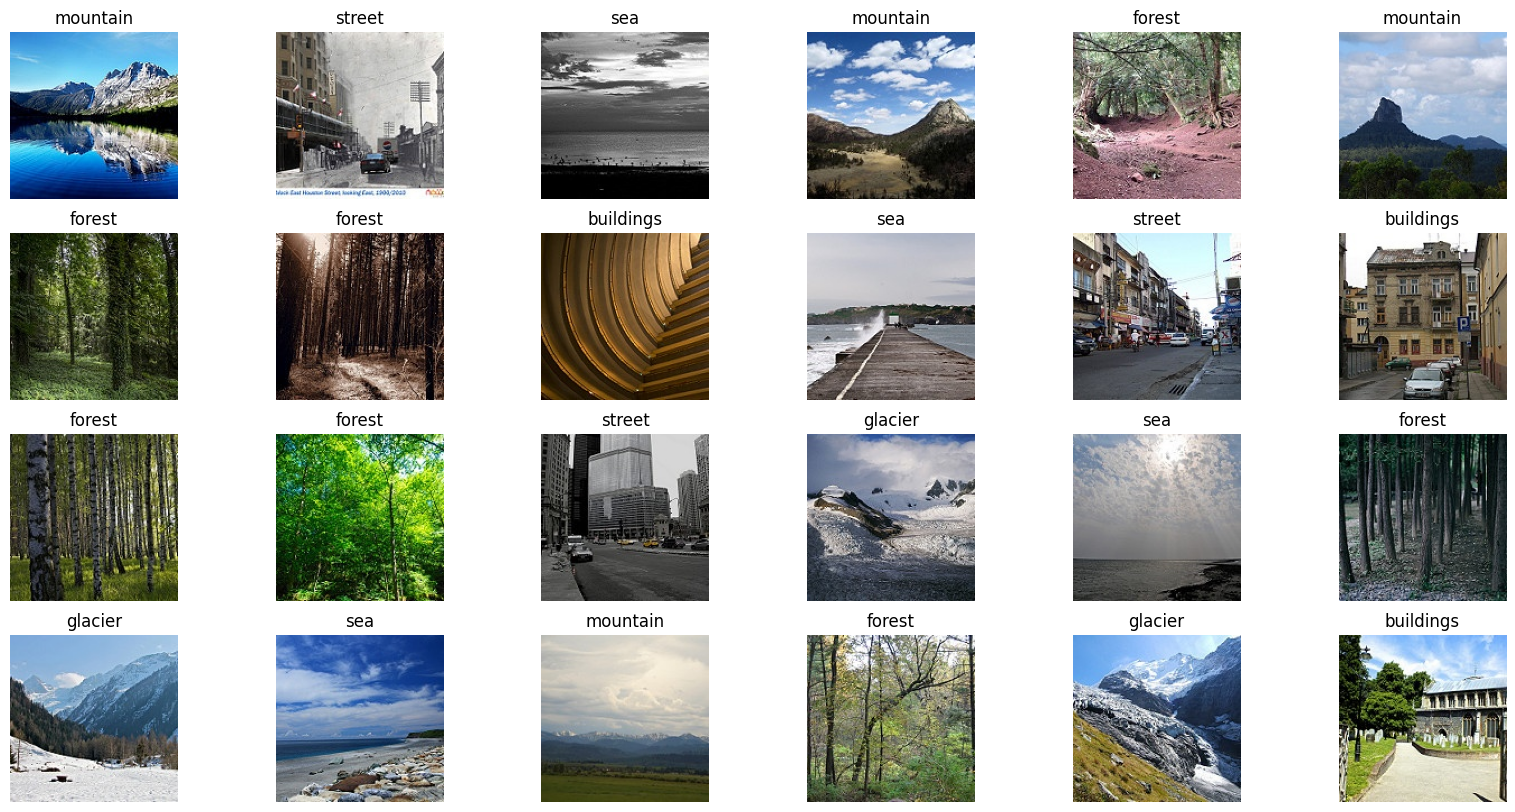

In [18]:
plt.figure(figsize=(20, 10))
for i in range(24):
  plt.subplot(4, 6, i+1)
  class_name = random.choice(class_names)
  img = view_random_image(target_dir='seg_train/',
                  target_class=class_name)

In [19]:
train_dir = "seg_train/"
test_dir = "seg_test/"

In [20]:
train_datagen = ImageDataGenerator(
    rescale=1/255.,
    rotation_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    vertical_flip=True
)

val_datagen = ImageDataGenerator(rescale = 1/255.)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size= (150, 150),
    batch_size= 32,
    class_mode= 'categorical'
)

test_data = val_datagen.flow_from_directory(
    test_dir,
    target_size= (150, 150),
    batch_size= 32,
    class_mode= 'categorical'
)

Found 14034 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.


In [21]:
model_1 = Sequential([
  Conv2D(16, 3, padding='same', activation='relu', input_shape=(150,150,3)),
  MaxPool2D(),
  Conv2D(32, 3, padding='same', activation='relu'),
  MaxPool2D(),
  Conv2D(64, 3, padding='same', activation='relu'),
  MaxPool2D(),
  Flatten(),
  Dense(128, activation='relu'),
  Dense(len(class_names), activation='softmax')
])

model_1.compile(loss="categorical_crossentropy",
              optimizer=Adam(),
              metrics=['accuracy'])
model_1.summary()



Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 150, 150, 16)      448       
                                                                 
 max_pooling2d (MaxPooling2  (None, 75, 75, 16)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 75, 75, 32)        4640      
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 37, 37, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 37, 37, 64)        18496     
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 18, 18, 64)       

In [22]:
history_1 = model_1.fit(train_data,
                    epochs=5,
                    batch_size=32,
                    steps_per_epoch=len(train_data),
                    validation_data=test_data,
                    validation_steps=len(test_data))

Epoch 1/5


439/439 [==============================] - 537s 1s/step - loss: 1.1425 - accuracy: 0.5422 - val_loss: 1.1546 - val_accuracy: 0.5770
Epoch 2/5
439/439 [==============================] - 178s 404ms/step - loss: 0.8883 - accuracy: 0.6577 - val_loss: 0.8707 - val_accuracy: 0.6793
Epoch 3/5
439/439 [==============================] - 78s 178ms/step - loss: 0.7665 - accuracy: 0.7159 - val_loss: 0.6403 - val_accuracy: 0.7663
Epoch 4/5
439/439 [==============================] - 85s 194ms/step - loss: 0.7062 - accuracy: 0.7382 - val_loss: 0.6285 - val_accuracy: 0.7747
Epoch 5/5
439/439 [==============================] - 88s 200ms/step - loss: 0.6334 - accuracy: 0.7656 - val_loss: 0.5515 - val_accuracy: 0.7990


In [23]:
model_1.evaluate(test_data)

94/94 [==============================] - 5s 49ms/step - loss: 0.5515 - accuracy: 0.7990


[0.5514618754386902, 0.7990000247955322]

Text(0, 0.5, 'Loss')

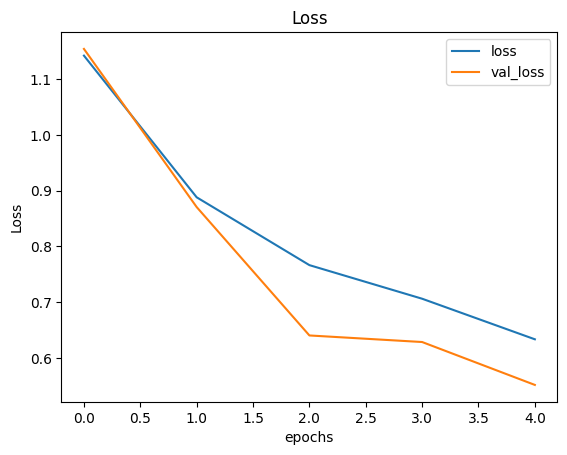

In [25]:
pd.DataFrame(history_1.history)[['loss','val_loss']].plot()
plt.title('Loss')
plt.xlabel('epochs')
plt.ylabel('Loss')

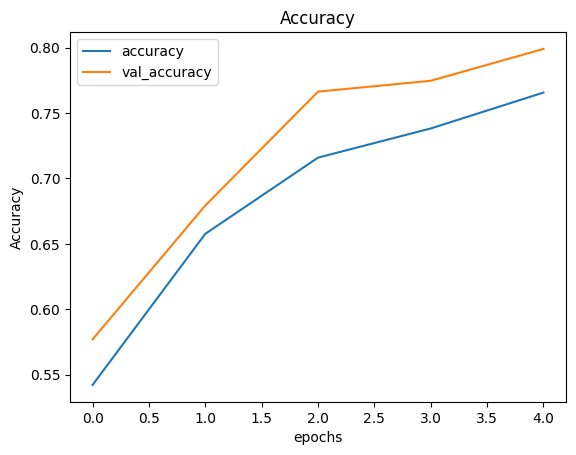

In [26]:
pd.DataFrame(history_1.history)[['accuracy', 'val_accuracy']].plot()
plt.title('Accuracy')
plt.xlabel('epochs')
plt.ylabel('Accuracy');

In [28]:
model_1.save('newmodel1/', save_format='tf')

INFO:tensorflow:Assets written to: newmodel1/assets


INFO:tensorflow:Assets written to: newmodel1/assets


In [34]:
!dir newmodel1

 Volume in drive C is Acer
 Volume Serial Number is A6B3-B12A

 Directory of c:\Users\yash2\Desktop\Model\newmodel1

24-03-2026  13:46    <DIR>          .
24-03-2026  13:46    <DIR>          ..
24-03-2026  13:46    <DIR>          assets
24-03-2026  13:46                56 fingerprint.pb
24-03-2026  13:46            20,231 keras_metadata.pb
24-03-2026  13:46           160,766 saved_model.pb
24-03-2026  13:46    <DIR>          variables
               3 File(s)        181,053 bytes
               4 Dir(s)  37,895,450,624 bytes free


In [35]:
model_loaded = tf.keras.models.load_model('newmodel1/')

In [36]:
model_loaded.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 150, 150, 16)      448       
                                                                 
 max_pooling2d (MaxPooling2  (None, 75, 75, 16)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 75, 75, 32)        4640      
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 37, 37, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 37, 37, 64)        18496     
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 18, 18, 64)        0

In [37]:
from PIL import Image
import numpy as np
from skimage import transform
def process(filename):
   np_image = Image.open(filename)
   np_image = np.array(np_image).astype('float32')
   np_image = transform.resize(np_image, (150, 150, 3))
   np_image = np.expand_dims(np_image, axis=0)
   return np_image

In [ ]:
pred_label=model_loaded.predict(process('download.jpg'))
print(class_names[np.argmax(pred_label)])  #wrong predicted

1/1 [==============================] - 0s 15ms/step
buildings


In [45]:
pred_label=model_loaded.predict(process('28.jpg'))
print(class_names[np.argmax(pred_label)])

1/1 [==============================] - 0s 16ms/step
mountain


In [46]:
pred_label=model_loaded.predict(process('152.jpg'))
print(class_names[np.argmax(pred_label)])

1/1 [==============================] - 0s 17ms/step
forest


In [47]:
pred_label=model_loaded.predict(process('101.jpg'))
print(class_names[np.argmax(pred_label)])

1/1 [==============================] - 0s 26ms/step
glacier


In [48]:
pred_label=model_loaded.predict(process('103.jpg'))
print(class_names[np.argmax(pred_label)])

1/1 [==============================] - 0s 25ms/step
buildings


In [49]:
pred_label

array([[1., 0., 0., 0., 0., 0.]], dtype=float32)

In [50]:
import tensorflow as tf
import streamlit as st
import PIL
import pandas as pd
import matplotlib
import numpy as np
import requests
import skimage

print("TensorFlow:", tf.__version__)
print("Streamlit:", st.__version__)
print("Pillow:", PIL.__version__)
print("Pandas:", pd.__version__)
print("Matplotlib:", matplotlib.__version__)
print("NumPy:", np.__version__)
print("Requests:", requests.__version__)
print("Scikit-image:", skimage.__version__)

TensorFlow: 2.15.0
Streamlit: 1.55.0
Pillow: 12.1.1
Pandas: 2.3.3
Matplotlib: 3.10.8
NumPy: 1.26.4
Requests: 2.32.5
Scikit-image: 0.26.0
